# 05 - Grad-CAM Explainability

Generate Grad-CAM heatmaps for `models/best_transfer_model.keras` (the winning transfer learning architecture from `04_TransferLearning.ipynb`), so predictions can be visually explained rather than trusted as a black box. Paths in this notebook match `04_TransferLearning.ipynb` (raw data unzipped to `/content/data/raw/`, models/outputs saved to Google Drive).

## Workflow

1. Mount Drive, load the saved `best_transfer_model.keras`.
2. Auto-detect which architecture it is.
3. Rebuild that architecture fresh in this session and copy the trained weights over (see note below for why).
4. Run Grad-CAM on a mix of correct and incorrect test predictions, across all four classes.
5. Save heatmap overlays to `outputs/gradcam/`.

**Why rebuild the model instead of using the loaded one directly?** Keras 3 has a known issue where nested `Functional` submodels (like the pretrained ResNet50/DenseNet121/EfficientNetB0 base, nested inside the full classification model) lose some internal graph bookkeeping when saved to `.keras` and reloaded. `model.predict()` on the reloaded model works fine, since it only uses the model's top-level composed call path -- but reaching into the nested submodel for an intermediate layer's output (which Grad-CAM requires) fails with a `KeyError` on a reloaded model. Rebuilding the exact same architecture fresh and copying the trained weights over sidesteps this entirely, since a freshly-built model has clean graph bookkeeping.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Create the target directory if it doesn't exist
!mkdir -p /content/data/raw/

# Unzip your data into the /content/data/raw/ directory
# Skips silently if already unzipped in this session.
!unzip -qn "/content/drive/MyDrive/raw_data.zip" -d /content/data/raw/

print("Data available at /content/data/raw/")

Data available at /content/data/raw/


In [3]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0
from tensorflow.keras.applications import resnet50, densenet, efficientnet

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)
if not gpus:
    print('No GPU detected -- Grad-CAM will still run fine on CPU for this notebook.')

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from __future__ import annotations
import os

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    PROJECT_ROOT = Path('/content/')  # matches your 04_TransferLearning.ipynb setup
    MODELS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/models')
    OUTPUTS_DIR = Path('/content/drive/MyDrive/brain_tumor_capstone/outputs')
else:
    def find_project_root(start: Path | None = None) -> Path:
        start = start or Path.cwd()
        for candidate in [start, *start.parents]:
            if (candidate / 'data' / 'raw' / 'Training').exists() and (candidate / 'data' / 'raw' / 'Testing').exists():
                return candidate
        raise FileNotFoundError('Could not locate data/raw/Training and data/raw/Testing.')

    PROJECT_ROOT = find_project_root()
    MODELS_DIR = PROJECT_ROOT / 'models'
    OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
TRAIN_DIR = RAW_DIR / 'Training'
TEST_DIR = RAW_DIR / 'Testing'
TRANSFER_MODELS_DIR = MODELS_DIR / 'transfer_learning'
GRADCAM_DIR = OUTPUTS_DIR / 'gradcam'
for folder in [GRADCAM_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

BEST_MODEL_PATH = MODELS_DIR / 'best_transfer_model.keras'

assert TEST_DIR.exists(), f"Test data not found at {TEST_DIR}."
assert BEST_MODEL_PATH.exists(), (
    f"{BEST_MODEL_PATH} not found. Run 04_TransferLearning.ipynb first -- "
    "it saves the winning architecture there."
)

IN_COLAB, PROJECT_ROOT, TEST_DIR, BEST_MODEL_PATH

(True,
 PosixPath('/content'),
 PosixPath('/content/data/raw/Testing'),
 PosixPath('/content/drive/MyDrive/brain_tumor_capstone/models/best_transfer_model.keras'))

## Load Test Data

Loaded fresh (not cached/transformed) so `.file_paths` stays available -- needed to display each image alongside its Grad-CAM heatmap.

In [6]:
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

class_names = test_ds.class_names
test_file_paths = test_ds.file_paths
num_classes = len(class_names)

class_names, len(test_file_paths)

Found 1600 files belonging to 4 classes.


(['glioma', 'meningioma', 'notumor', 'pituitary'], 1600)

## Load the Best Model

In [7]:
best_model = keras.models.load_model(BEST_MODEL_PATH)
best_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,276,430 (203.23 MB)

 Trainable params: 14,712,964 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 29,425,930 (112.25 MB)

In [8]:
# The pretrained base model is nested as a single named layer inside best_model
# (its name matches its architecture key, e.g. 'resnet50', since that's Keras's
# default naming for these application models).
KNOWN_ARCHITECTURES = ['resnet50', 'densenet121', 'efficientnetb0']

base_model_key = None
for layer in best_model.layers:
    if layer.name in KNOWN_ARCHITECTURES:
        base_model_key = layer.name
        break

if base_model_key is None:
    raise ValueError(
        f"Could not find a recognized base architecture among best_model's layers: "
        f"{[l.name for l in best_model.layers]}"
    )

print(f'Detected architecture: {base_model_key}')
print(f'Base model output shape: {best_model.get_layer(base_model_key).output.shape}')

Detected architecture: resnet50
Base model output shape: (None, 7, 7, 2048)


## Rebuild the Model Fresh and Copy Trained Weights

See the note above -- this rebuilds the exact same architecture used in `04_TransferLearning.ipynb`, then copies the trained weights from the reloaded `best_model` onto it. The sanity check confirms the rebuild is weight-identical to the original.

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10, value_range=(0, 255)),
], name='augmentation')

MODEL_CONFIGS = {
    'resnet50': {'base_class': ResNet50, 'preprocess_fn': resnet50.preprocess_input},
    'densenet121': {'base_class': DenseNet121, 'preprocess_fn': densenet.preprocess_input},
    'efficientnetb0': {'base_class': EfficientNetB0, 'preprocess_fn': efficientnet.preprocess_input},
}

def build_transfer_model(model_key, num_classes):
    config = MODEL_CONFIGS[model_key]
    base_model = config['base_class'](
        include_top=False, weights=None, input_shape=IMG_SIZE + (3,)
    )

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = config['preprocess_fn'](x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name=model_key)
    return model, base_model

fresh_model, fresh_base = build_transfer_model(base_model_key, num_classes=len(class_names))
fresh_model.set_weights(best_model.get_weights())  # weights=None above is fine, this overwrites everything

# Sanity check: predictions should match the original loaded model almost exactly
sample_batch = next(iter(test_ds))[0][:4]
original_preds = best_model.predict(sample_batch, verbose=0)
fresh_preds = fresh_model.predict(sample_batch, verbose=0)
max_diff = np.abs(original_preds - fresh_preds).max()
print('Max prediction difference between original and rebuilt model:', max_diff)
assert max_diff < 1e-4, 'Rebuilt model predictions do not match the original -- check the architecture matches exactly.'

Max prediction difference between original and rebuilt model: 0.0


## Build the Grad-CAM Model

Built on `fresh_model` (clean graph bookkeeping), not the reloaded `best_model`.

In [10]:
grad_model = keras.Model(
    inputs=fresh_model.inputs,
    outputs=[fresh_model.get_layer(base_model_key).output, fresh_model.output],
)

In [15]:
def make_gradcam_heatmap(img_array, model, base_model_key, pred_index=None):
    """
    img_array: shape (1, H, W, 3), raw 0-255 float.
    Manually replays the model's layers in eager mode -- avoids a Keras 3
    limitation where building a new graph-based model around a nested
    Functional submodel's intermediate output is unreliable.
    """
    x = tf.convert_to_tensor(img_array)
    conv_output = None

    with tf.GradientTape() as tape:
        for layer in model.layers:
            if layer.__class__.__name__ == 'InputLayer':
                continue
            x = layer(x, training=False)
            if layer.name == base_model_key:
                conv_output = x
                tape.watch(conv_output)
        predictions = x
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index, predictions.numpy()[0]

## Run Predictions on the Test Set

Uses `best_model` (the reloaded one) -- `.predict()` works fine on it, since only reaching into the nested submodel for an intermediate layer was broken, not top-level prediction. Used to pick a representative mix of correct and incorrect predictions per class for Grad-CAM.

In [16]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_prob.extend(preds.tolist())

results_df = pd.DataFrame({
    'file_path': test_file_paths,
    'true_label': [class_names[i] for i in y_true],
    'pred_label': [class_names[i] for i in y_pred],
    'true_idx': y_true,
    'pred_idx': y_pred,
    'confidence': [y_prob[i][y_pred[i]] for i in range(len(y_pred))],
})
results_df['correct'] = results_df['true_idx'] == results_df['pred_idx']

print(f"Overall test accuracy: {results_df['correct'].mean():.4f}")
results_df.head()

Overall test accuracy: 0.9069


,file_path,true_label,pred_label,true_idx,pred_idx,confidence,correct
0,/content/data/raw/Testing/glioma/Te-gl_1.jpg,glioma,glioma,0,0,0.762719,True
1,/content/data/raw/Testing/glioma/Te-gl_10.jpg,glioma,glioma,0,0,1.000000,True
2,/content/data/raw/Testing/glioma/Te-gl_100.jpg,glioma,glioma,0,0,1.000000,True
3,/content/data/raw/Testing/glioma/Te-gl_101.jpg,glioma,pituitary,0,3,0.633189,False
4,/content/data/raw/Testing/glioma/Te-gl_102.jpg,glioma,glioma,0,0,0.968194,True


## Select Sample Images

One correct and one incorrect prediction per class where available (some classes may have very few or no misclassifications).

In [18]:
samples = []
for class_name in class_names:
    class_rows = results_df[results_df['true_label'] == class_name]

    correct_rows = class_rows[class_rows['correct']]
    if not correct_rows.empty:
        samples.append(correct_rows.sample(1, random_state=SEED).iloc[0])

    incorrect_rows = class_rows[~class_rows['correct']]
    if not incorrect_rows.empty:
        samples.append(incorrect_rows.sample(1, random_state=SEED).iloc[0])

samples_df = pd.DataFrame(samples).reset_index(drop=True)
samples_df[['file_path', 'true_label', 'pred_label', 'confidence', 'correct']]

,file_path,true_label,pred_label,confidence,correct
0,/content/data/raw/Testing/glioma/Te-gl_361.jpg,glioma,glioma,1.000000,True
1,/content/data/raw/Testing/glioma/Te-gl_62.jpg,glioma,notumor,0.582201,False
2,/content/data/raw/Testing/meningioma/Te-me_119...,meningioma,meningioma,0.979715,True
3,/content/data/raw/Testing/meningioma/Te-me_133...,meningioma,pituitary,0.835439,False
4,/content/data/raw/Testing/notumor/Te-no_279.jpg,notumor,notumor,0.999781,True
5,/content/data/raw/Testing/notumor/Te-no_96.jpg,notumor,meningioma,0.523256,False
6,/content/data/raw/Testing/pituitary/Te-pi_17.jpg,pituitary,pituitary,0.999957,True
7,/content/data/raw/Testing/pituitary/Te-pi_219.jpg,pituitary,meningioma,0.617575,False


## Generate and Display Grad-CAM Heatmaps

/tmp/ipykernel_1118/488315862.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


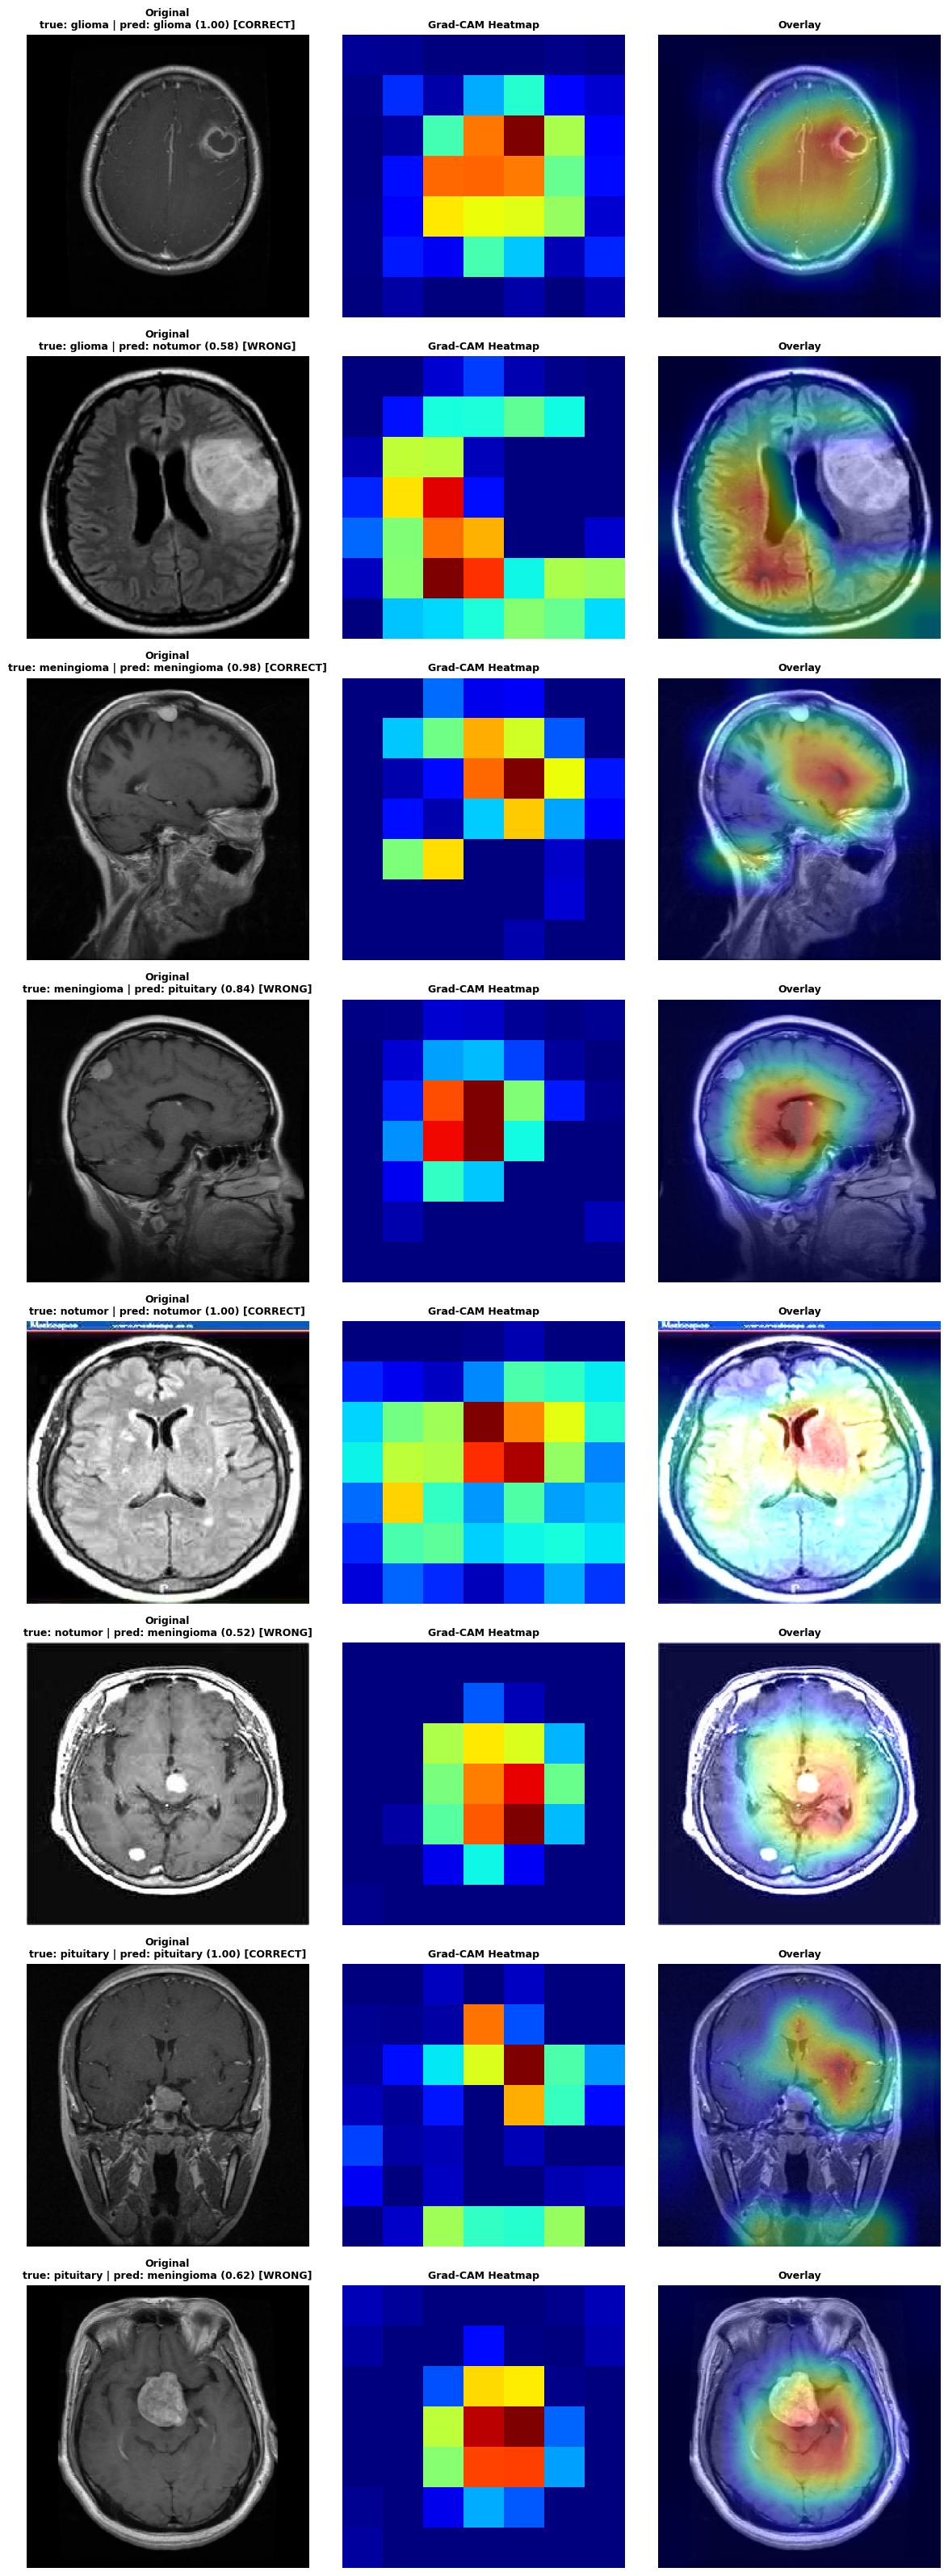

In [19]:
def load_image_array(file_path, target_size=IMG_SIZE):
    img = keras.utils.load_img(file_path, target_size=target_size)
    return keras.utils.img_to_array(img)  # raw 0-255 float, shape (H, W, 3)


n_samples = len(samples_df)
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
if n_samples == 1:
    axes = axes.reshape(1, -1)

for row_index, sample in samples_df.iterrows():
    img_array = load_image_array(sample['file_path'])
    img_batch = np.expand_dims(img_array, axis=0)

    heatmap, pred_index, probs = make_gradcam_heatmap(img_batch, fresh_model, base_model_key)
    overlay = overlay_heatmap(img_array, heatmap)

    status = 'CORRECT' if sample['correct'] else 'WRONG'
    title_suffix = f"true: {sample['true_label']} | pred: {sample['pred_label']} ({sample['confidence']:.2f}) [{status}]"

    axes[row_index, 0].imshow(img_array.astype('uint8'))
    axes[row_index, 0].set_title(f"Original\n{title_suffix}", fontsize=9)
    axes[row_index, 0].axis('off')

    axes[row_index, 1].imshow(heatmap, cmap='jet')
    axes[row_index, 1].set_title('Grad-CAM Heatmap', fontsize=9)
    axes[row_index, 1].axis('off')

    axes[row_index, 2].imshow(overlay)
    axes[row_index, 2].set_title('Overlay', fontsize=9)
    axes[row_index, 2].axis('off')

    save_name = f"{row_index:02d}_{sample['true_label']}_{status.lower()}.png"
    plt.imsave(GRADCAM_DIR / save_name, overlay)

plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'gradcam_grid.png', dpi=200, bbox_inches='tight')
plt.show()

## Interpretation Notes

For each row above:

- **Correct predictions**: check whether the heatmap concentrates on the actual tumor region (or, for `notumor`, spreads diffusely rather than fixating on one spot) -- this is the difference between the model learning real diagnostic features versus learning a spurious shortcut (e.g. image borders, scanner artifacts, brightness) that happens to correlate with the label.
- **Incorrect predictions**: check whether the heatmap still lands on a real anatomical structure (understandable ambiguity, e.g. glioma/meningioma texture overlap) versus focusing on something irrelevant (a genuine failure mode worth calling out in your report).

Given the confusion matrix history from `03_Model_Training.ipynb` and `04_TransferLearning.ipynb`, the glioma/meningioma pair is the most interesting one to examine closely here -- if the heatmaps for misclassified meningioma-as-glioma cases show the model attending to a plausible tumor-like region rather than noise, that supports the explanation that these two classes have genuinely overlapping visual presentation on MRI, rather than the model being unreliable.